In [1]:
%matplotlib ipympl

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import decimal
from collections import namedtuple
from statistics import mean

In [3]:
class Event(namedtuple("Event", ["benchmark","type","iterations","n","event","iteration","realtime","monotonic","cpu"])):
    @classmethod
    def fromCsv(cls, row):
        row.update(
            iterations = int(row['iterations']),
            n = int(row['n']),
            iteration = int(row['iteration']) if row['iteration'] != '' else None,
            realtime = decimal.Decimal(row['realtime']),
            monotonic = decimal.Decimal(row['monotonic']),
            cpu = decimal.Decimal(row['cpu']))
        return cls.__new__(cls, **row)


In [4]:
def makeSeries(benchmark):
        ns = []
        xs = {}
        for (n, bench) in benchmark.items():
            ns.append(n)
            for clk in ["realtime","monotonic","cpu"]:
                xs.setdefault(clk, []).append(mean(
                    (float(getattr(x['END'],clk) - getattr(x['START'],clk)))
                    for x in bench["runs"].values()))
        return (ns, xs)

class Benchmarks:
    def __init__(self, csvPath):
        self.benchmarks = benchmarks = {}

        with open(csvPath) as csvfile:
            for row in csv.DictReader(csvfile):
                event = Event.fromCsv(row)
                benchmark = benchmarks.setdefault(event.benchmark, {})
                benchmarkT = benchmark.setdefault(event.type, {})
                benchmarkN = benchmarkT.setdefault(event.n, {"runs":{}})
                if event.iteration is None:
                    benchmarkN[event.event] = event
                else:
                    benchmarkN["runs"].setdefault(event.iteration, {})[event.event] = event 

    
    def makePlot(self, benchName, clk="monotonic"):
        bench = self.benchmarks[benchName]
        benchSeries = { k: makeSeries(v) for (k, v) in bench.items() }
        fig, ax = plt.subplots()
        ax.set_xlabel("n")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylabel("time(sec)")
        for (tyNm, ser) in benchSeries.items():
            ax.plot(ser[0], ser[1][clk], label=tyNm)
        ax.legend()
        ax.set_title(benchName)
        
    def makeAllPlots(self, clk="monotonic"):
        for bName in self.benchmarks.keys():
            self.makePlot(bName, clk)

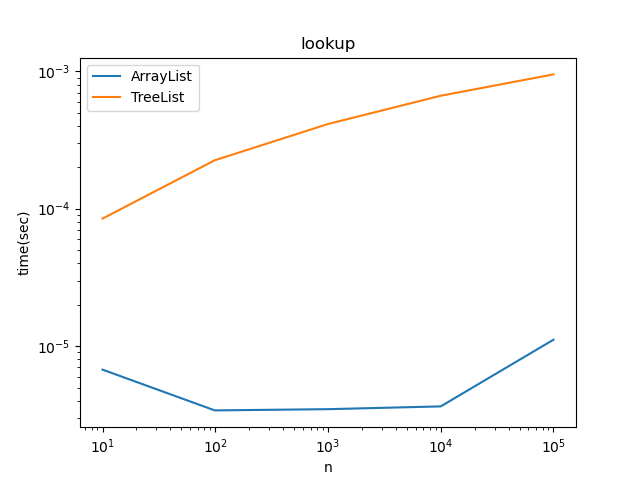

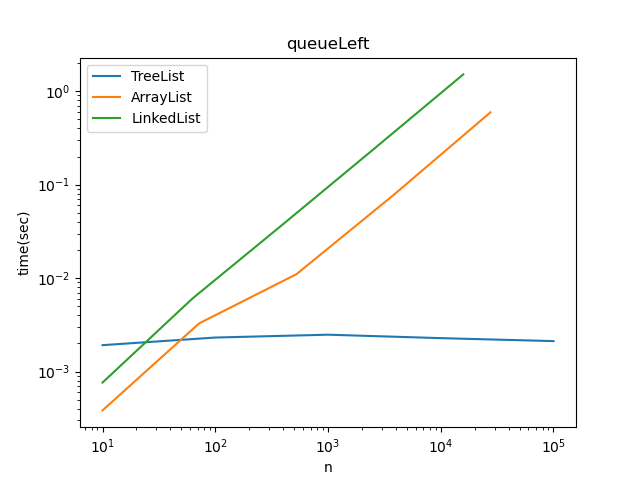

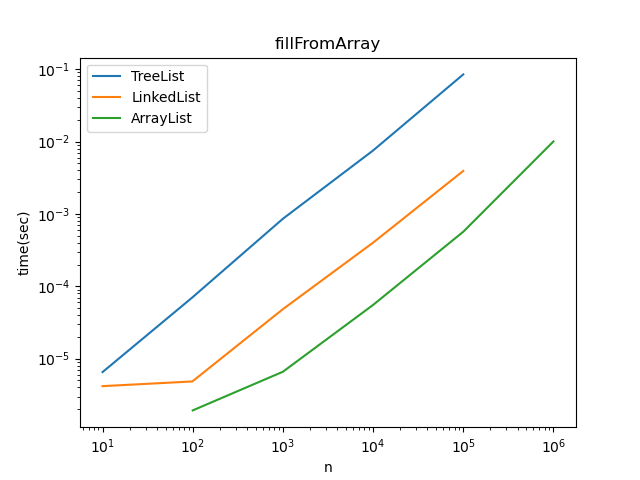

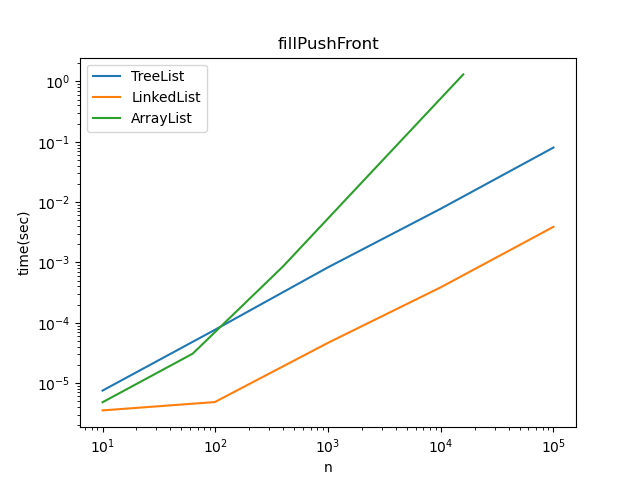

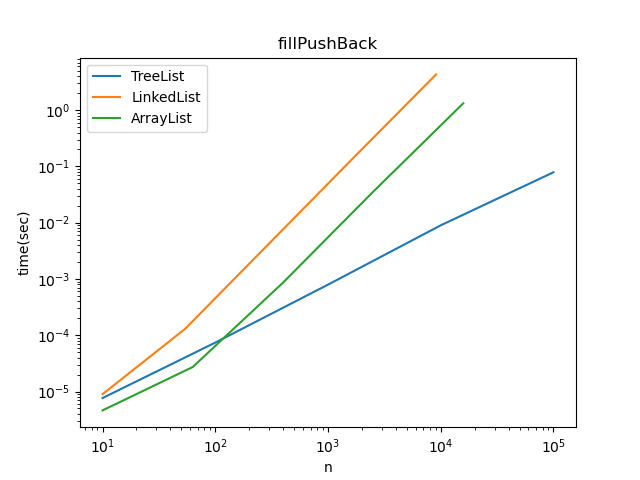

In [6]:
theBenchmarks = Benchmarks("bench.csv")
theBenchmarks.makeAllPlots()